# Modeling — Random Forest Regressor
## Prediksi Hasil Panen Tanaman Berbasis Data Iklim dan Nutrisi Tanaman

| Informasi | Detail |
|-----------|--------|
| Algoritma | Random Forest Regressor |
| Target | `yield_hg_ha` (hasil panen dalam hg/ha) |
| Fitur | area, item, year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp |
| Data Train | X_train.csv / y_train.csv |
| Data Test | X_test.csv / y_test.csv |

---

## 0. Import Library dan Load Data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('output', exist_ok=True)

X_train = pd.read_csv('output/X_train.csv')
X_test  = pd.read_csv('output/X_test.csv')
y_train = pd.read_csv('output/y_train.csv').squeeze()
y_test  = pd.read_csv('output/y_test.csv').squeeze()

print('Data berhasil dimuat.')
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

Data berhasil dimuat.
X_train : (22593, 6)
X_test  : (5649, 6)
y_train : (22593,)
y_test  : (5649,)


---
## 5.1 Training Model Random Forest Regressor

In [2]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print('Model berhasil dilatih.')
print('Konfigurasi Model:')
print(f'  n_estimators    : {model.n_estimators}')
print(f'  max_depth       : {model.max_depth}')
print(f'  min_samples_split: {model.min_samples_split}')
print(f'  min_samples_leaf : {model.min_samples_leaf}')

Model berhasil dilatih.
Konfigurasi Model:
  n_estimators    : 100
  max_depth       : None
  min_samples_split: 2
  min_samples_leaf : 1


---
## 6.1 Evaluasi Model

In [3]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

print('Evaluasi Model Random Forest Regressor')
print('=======================================')
print(f'{"Metrik":<10} {"Train":>12} {"Test":>12}')
print(f'{"-"*35}')
print(f'{"MAE":<10} {mae_train:>12.2f} {mae_test:>12.2f}')
print(f'{"RMSE":<10} {rmse_train:>12.2f} {rmse_test:>12.2f}')
print(f'{"R2":<10} {r2_train:>12.4f} {r2_test:>12.4f}')

Evaluasi Model Random Forest Regressor
Metrik            Train         Test
-----------------------------------
MAE             1400.17      3763.01
RMSE            3789.73     10205.88
R2               0.9980       0.9856


---
## 6.2 Visualisasi Prediksi vs Aktual

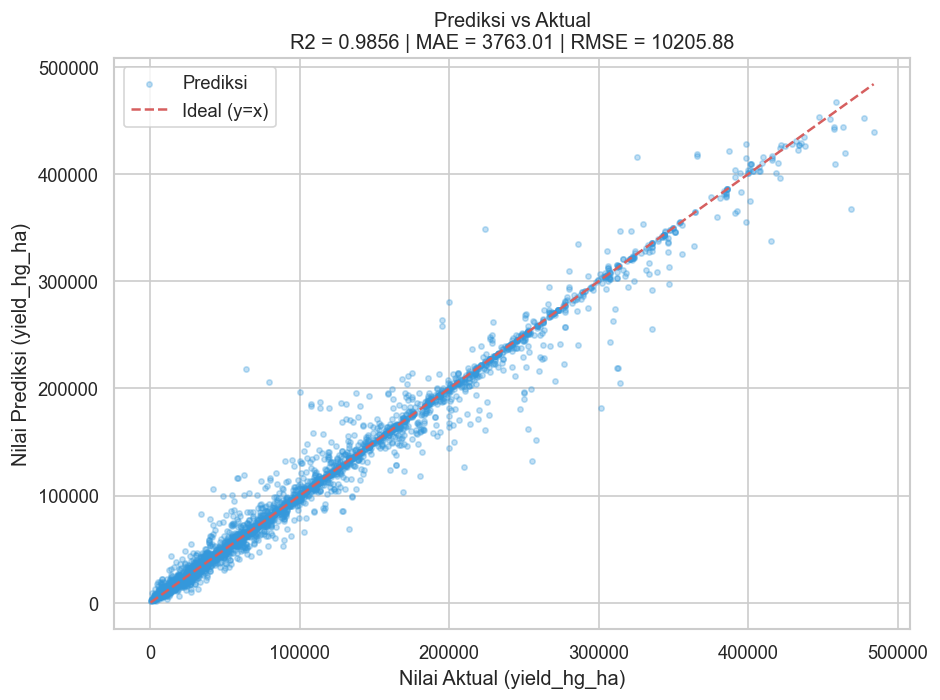

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='#3498DB', label='Prediksi')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Ideal (y=x)')

ax.set_xlabel('Nilai Aktual (yield_hg_ha)')
ax.set_ylabel('Nilai Prediksi (yield_hg_ha)')
ax.set_title(f'Prediksi vs Aktual\nR2 = {r2_test:.4f} | MAE = {mae_test:.2f} | RMSE = {rmse_test:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('output/modeling_pred_vs_actual.png', bbox_inches='tight')
plt.show()

---
## 6.3 Distribusi Error (Residual)

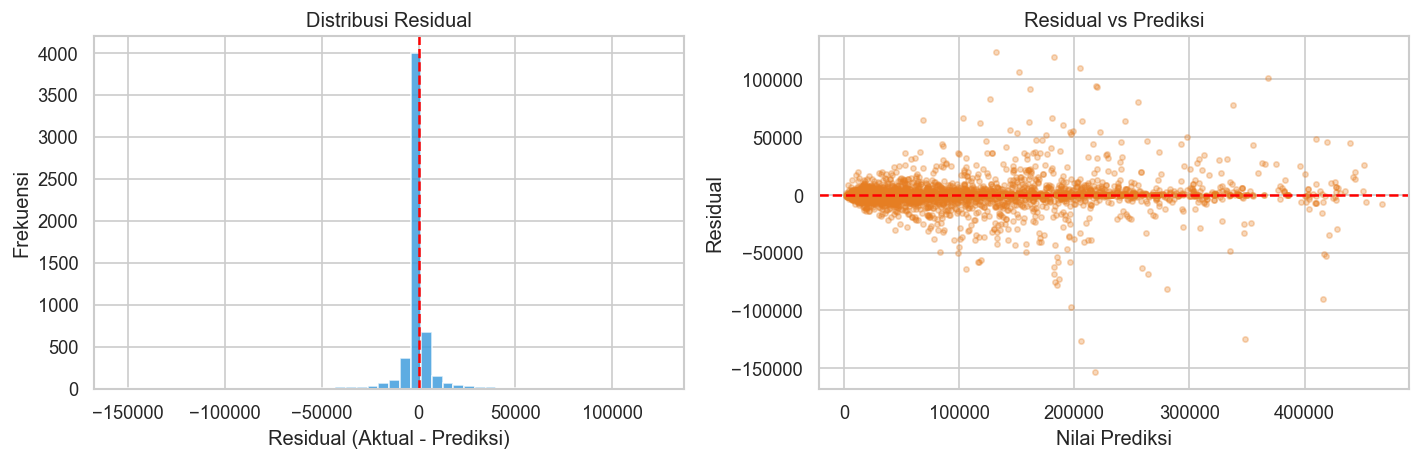

Mean Residual  : -64.3476 (mendekati nol = bagus)
Std  Residual  : 10205.6729


In [5]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (Aktual - Prediksi)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Residual')

axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=10, color='#E67E22')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Nilai Prediksi')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs Prediksi')

plt.tight_layout()
plt.savefig('output/modeling_residual.png', bbox_inches='tight')
plt.show()

print(f'Mean Residual  : {residuals.mean():.4f} (mendekati nol = bagus)')
print(f'Std  Residual  : {residuals.std():.4f}')

---
## 7.1 Feature Importance

In [6]:
feature_names = X_train.columns.tolist()
importances   = model.feature_importances_

importance_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Feature Importance (diurutkan tertinggi ke terendah):')
print('=======================================================')
for _, row in importance_df.iterrows():
    bar = '#' * int(row['Importance'] * 50)
    print(f"  {row['Fitur']:<40}: {row['Importance']:.4f}  {bar}")

Feature Importance (diurutkan tertinggi ke terendah):
  item                                    : 0.6087  ##############################
  pesticides_tonnes                       : 0.1098  #####
  avg_temp                                : 0.1086  #####
  average_rain_fall_mm_per_year           : 0.0866  ####
  area                                    : 0.0549  ##
  year                                    : 0.0313  #


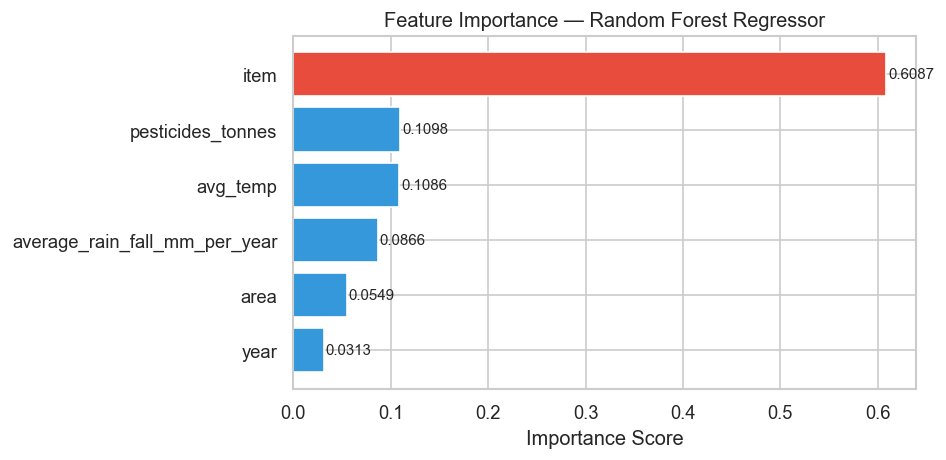

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_imp = ['#E74C3C' if i == 0 else '#3498DB' for i in range(len(importance_df))]
bars = ax.barh(importance_df['Fitur'][::-1], importance_df['Importance'][::-1],
               color=colors_imp[::-1], edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest Regressor')
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('output/modeling_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 7.2 Rangkuman Hasil dan Kesimpulan

In [8]:
print('=' * 60)
print('  RANGKUMAN HASIL MODELING')
print('=' * 60)
print(f'  Algoritma        : Random Forest Regressor')
print(f'  n_estimators     : {model.n_estimators}')
print()
print(f'  Metrik Evaluasi (Data Test):')
print(f'    MAE    : {mae_test:.2f}')
print(f'    RMSE   : {rmse_test:.2f}')
print(f'    R2     : {r2_test:.4f}')
print()
print(f'  Fitur paling dominan:')
for i, row in importance_df.head(3).iterrows():
    print(f"    {i+1}. {row['Fitur']} ({row['Importance']:.4f})")
print('=' * 60)

  RANGKUMAN HASIL MODELING
  Algoritma        : Random Forest Regressor
  n_estimators     : 100

  Metrik Evaluasi (Data Test):
    MAE    : 3763.01
    RMSE   : 10205.88
    R2     : 0.9856

  Fitur paling dominan:
    1. item (0.6087)
    2. pesticides_tonnes (0.1098)
    3. avg_temp (0.1086)
